---
title: Computing Leaf Area Index with Sentinel-2 in EOPF Zarr format
subtitle: LAI with Sentinel-2
authors:
  - name: Gaia Vallarino
    orcid: 0000-0003-3680-381X
    github: ?
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Yuvraj Bhagwan Adagale
    orcid: 0009-0008-1259-3399
    github: Yuvraj198920
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Juraj Zvolenský
    orcid: 0009-0000-9185-7955
    github: jzvolensky
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
date: 2026-05-07
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["earth observation", "remote sensing","LAI", "sentinel-2","hybrid modelling"]
tags: ["Sentinel-2","biophysical variable retrieval","LAI", "sentinel-2", "hybrid modelling"]
releaseDate: 2026-05-07
datePublished: 2026-05-07
dateModified: 2026-05-07
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of Contents

- [Introduction](#introduction)
- [Setup](#setup)
- [STAC Search](#stac-search)
- [SL2P Biophysical variable retrieval](#sl2p-biophysical-variable-retrieval)
- [Parameters](#parameters)
- [Validation and options](#validation-and-options)

(Introduction-LAI-S2)=
## Introduction

This notebook focuses on retrieving **Leaf Area Index** (LAI) from Sentinel-2 data using the **Simplified Level 2 Prototype Processor** (SL2P) framework [_Weiss & Baret 2016_] as implemented by [Djamai et al., 2024](https://github.com/djamainajib/SL2P-PYTHON). 

**LAI** is a key biophysical variable for describing vegetation canopy structure and is defined “total leaf area per unit of ground area" [_Watson, 1947_]. In practice, LAI is widely used to monitor vegetation productivity, evapotranspiration, and drought through vegetation status and land–atmosphere interactions from remote sensing data.

**SL2P** is a physics-informed hybrid retrieval model. It is useful because it provides an operational way to estimate vegetation biophysical variables such as LAI from Sentinel-2 reflectance data. It combines simulations derived from the radiative transfer model PROSAIL [_Jacquemoud et al., 2009_] with deep learning based retrievals, making it suitable for large-scale, repeatable processing of satellite imagery. 

This notebook is therefore useful both for understanding the SL2P workflow and for building a reproducible Python-based implementation for LAI retrieval.

_Dj
amai N., Fernandes, R.A. Sun. L., Canisius, F. and Hong. G, 2024. Python version of Simplified Level 2 Prototype
Processor for Retrieving Canopy Biophysical Variables from Sentinel 2 Multispectral Instrument Data, Open File_

_Jacquemoud, S., Verhoef, W., Baret, F., Bacour, C., Zarco-Tejada, P. J., Asner, G. P., François, C., & Ustin, S. L. (2009). "PROSPECT+SAIL models: A review of use for vegetation characterization." Remote Sensing of Environment, 113, S56–S66_

_Weiss, M., & Baret, F. (2016). S2ToolBox Level 2 Products: LAI, FAPAR, FCOVER (Version 1.1). Institut National de la Recherche Agronomique (INRA), Avignon, France._

_Watson, D. J. (1947). Comparative physiological studies on the growth of field crops: I. Variation in net assimilation rate and leaf area between species and varieties, and within and between years. Annals of Botany, 11(41), 41–76_

(Setup-LAI-S2)=
## Setup

In [ ]:
import os
import re
import time
import gc
import io
import warnings
import xarray as xr
import xarray_eopf
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac_client
import geopandas as gpd
from contextlib import redirect_stdout
from pyproj import Transformer
from pathlib import Path
from joblib import Parallel, delayed
from typing import Tuple
import rasterio
from sl2p.tools import SL2P, dictionariesSL2P
from sl2p.tools.xarray_utils import varmap_to_dataset
from sl2p.tools.xarray_utils import (
    ensure_angle_cosines,
    clip_cube_to_aoi,
    infer_profile,
)
from sl2p.tools.xarray_utils import build_sl2p_input

## Ignore RuntimeWarning for data cast
warnings.filterwarnings("ignore", category=RuntimeWarning)

(Stac-search-LAI-S2)=
## STAC Search

In [2]:
# Define AOI and convert to raster CRS (area above Bolzano, tile T32TPS)
spatial_extent = {
    "west": 11.317977240260499,
    "east": 11.3657883455519,
    "south": 46.483131171916064,
    "north": 46.50351101219372,
}

bbox_4326 = [
    spatial_extent["west"],
    spatial_extent["south"],
    spatial_extent["east"],
    spatial_extent["north"],
]

# Connect to the STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

# Search for Sentinel-2 L2A items within a specific bounding box and date range
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox_4326,
    datetime="2023-04-30/2023-10-31",
)

# Retrieve the list of matching items
items = list(search.items())
items = [
    it
    for it in items
    # Filter only for cpm_v260 products, which are the ones we are interested in
    if any("cpm_v260" in asset.href.lower() for asset in it.assets.values())
]
hrefs = [item.assets["product"].href for item in items]

if not hrefs:
    raise RuntimeError(
        "No Sentinel-2 products matching the query in the STAC catalogue"
    )

(SL2P-biophysical-variable-retrieval-LAI-S2)=
## SL2P biophysical variable retrieval

Run SL2P on preprocessed Sentinel-2 Zarr cubes.

Expected inputs (from LAI_data_preprocess.ipynb):
- 10 m grid
- Bands: B03,B04,B05,B06,B07,B8A,B11,B12 (SCL optional)
- Angular features already as cosines: cosSZA, cosVZA, cosRAA

In [ ]:
"""Run SL2P directly on preprocessed Sentinel-2 xarray cubes.

Expected per-product inputs:
- 10 m grid
- Bands: B03,B04,B05,B06,B07,B8A,B11,B12 (SCL optional)
- Angular features already as cosines: cosSZA, cosVZA, cosRAA
"""

(Parameters-LAI-S2)=

## Parameters

In [ ]:
variableName = "LAI"  # fAPAR, fCOVER, CWC, CCC, LAI, Albedo
imageCollectionName = "S2_10m"  # cubes already at 10 m
method = "SL2P"  # SL2P or SL2PCCRS
# Zarr cubes are already scaled to surface reflectance (0-1), so skip SL2P pre-scaling.
PRESCALED_INPUT = True
# (Opt.) Clipping to AOI - requires AOI shapefile. Reduces processing time and output file size.
clipping = True
AOI_path = "geojson/test_sites.geojson"

if clipping and not os.path.exists(AOI_path):
    raise FileNotFoundError(f"AOI shapefile not found: {AOI_path}")
if clipping:
    aoi = gpd.read_file(AOI_path)
    if aoi.empty:
        raise ValueError(f"AOI file contains no features: {AOI_path}")
    aoi = aoi.iloc[[0]]

out_dir = "./tmp/"

if clipping:
    out_dir = os.path.join(out_dir)
os.makedirs(out_dir, exist_ok=True)

(Validation-and-options-LAI-S2)=
## Validation and options

In [5]:
if variableName not in dictionariesSL2P.make_net_options():
    raise ValueError(f"Unsupported variable {variableName}")

net_options = dictionariesSL2P.make_net_options()[variableName][imageCollectionName]
required_inputs = net_options["inputBands"]
print(
    f"The required input layers for the SL2P {variableName} at 10 meters are: {required_inputs}"
)

The required input layers for the SL2P LAI at 10 meters are: ['cosVZA', 'cosSZA', 'cosRAA', 'B03', 'B04', 'B05', 'B06', 'B07', 'B8A', 'B11', 'B12']


(Data-preprocessing-LAI-S2)=

## Data preprocessing

- Read the data from the urls obtained from the STAC Items
- Combine the Sentinel-2 bands with the sun angles
- Clips to the area of interest extent (minimum bounding box around it)
- Stores the clipped pre-processed cube in a Zarr (necessary for memory management)
- Finally recombines all the Zarr products into an Xarray Dataset loaded in memory

In [ ]:
def prepare_sl2p_LAI_10m(url, aoi):
    # Use xarray-eopf to create a 10 m data cube and keep only the bands
    # required by the SL2P workflow.
    ds = xr.open_dataset(
        url,
        engine="eopf-zarr",
        op_mode="analysis",
        interp_methods="nearest",
    ).astype(np.float32)
    keys = list(ds.data_vars)
    values = [d.upper() for d in ds.data_vars]
    ds = ds.rename_vars(dict(zip(keys, values)))
    ds = ds[["B03", "B04", "B05", "B06", "B07", "B8A", "B11", "B12", "SCL"]]

    # Open the product as a DataTree to retrieve the sun and viewing angles,
    # then combine the interpolated angular cosines with the data cube.
    dt = xr.open_datatree(url, engine="zarr")
    product_datetime = dt.attrs["stac_discovery"]["properties"]["datetime"]
    SZA = (
        dt["conditions/geometry/sun_angles"]
        .sel(angle="zenith")
        .drop_vars("angle")
        .astype(np.float32)
    )
    SAA = (
        dt["conditions/geometry/sun_angles"]
        .sel(angle="azimuth")
        .drop_vars("angle")
        .astype(np.float32)
    )
    VZA_VAA = (
        dt["conditions/geometry/viewing_incidence_angles"]
        .loc[dict(band="b08")]
        .drop_vars("band")
        .mean(dim="detector")
        .astype(np.float32)
    )
    VZA = VZA_VAA.sel(angle="zenith").drop_vars("angle")
    VAA = VZA_VAA.sel(angle="azimuth").drop_vars("angle")
    RAA = np.absolute(SAA - VAA)

    ds["cosSZA"] = np.cos(np.deg2rad(SZA)).interp_like(ds)
    ds["cosVZA"] = np.cos(np.deg2rad(VZA)).interp_like(ds)
    ds["cosRAA"] = np.cos(np.deg2rad(RAA)).interp_like(ds)
    ds = ds.assign_coords(time=product_datetime).expand_dims("time")
    ds_clip = ds.loc[
        dict(
            x=slice(aoi.bounds.minx.item(), aoi.bounds.maxx.item()),
            y=slice(aoi.bounds.maxy.item(), aoi.bounds.miny.item()),
        )
    ]
    ds_clip.to_zarr(f"{out_dir}s2_preproc_{product_datetime}.zarr")
    del ds, ds_clip
    gc.collect()
    return

Run the data pre-processing in parallel using 3 cores.
Max number on EOPF JupyterLab, otherwise the memory will be filled and the kernel will crash.

In [7]:
%%time
_ = Parallel(n_jobs=3)(delayed(prepare_sl2p_LAI_10m)(url, aoi) for url in hrefs)

CPU times: user 1.18 s, sys: 526 ms, total: 1.71 s
Wall time: 3min 37s


Open the multiple Zarr products as a single Xarray object:

In [8]:
ds_time_series = xr.open_mfdataset(
    [p for p in Path(out_dir).glob("*.zarr")],
    engine="zarr",
    chunks={},
    concat_dim="time",
    combine="nested",
    decode_cf=False,
    mask_and_scale=False,
).drop_vars("spatial_ref")
ds_time_series

<xarray.Dataset> Size: 470kB
Dimensions:  (time: 74, y: 10, x: 13)
Coordinates:
  * time     (time) <U27 8kB '2023-09-13T10:16:31.024000Z' ... '2023-07-05T10...
  * x        (x) float32 52B 6.864e+05 6.865e+05 ... 6.866e+05 6.866e+05
  * y        (y) float32 40B 5.156e+06 5.156e+06 ... 5.156e+06 5.156e+06
Data variables:
    B03      (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    B04      (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    B05      (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    B06      (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    B07      (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    B11      (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    B12      (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    B8A      (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    SCL      (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    cosRAA   (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    cosSZA   (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
    cosVZA   (time, y, x) float32 38kB dask.array<chunksize=(1, 10, 13), meta=np.ndarray>
Attributes: (12/25)
    AOT_retrieval_model:                                                     ...
    NUC_table_ID:                                                            ...
    SWIR_rearrangement_flag:                                                 ...
    UTM_zone_identification:                                                 ...
    band_description:                                                        ...
    declared_accuracy_of_AOT_model:                                          ...
    ...                                                                                                       ...
    onboard_equalization_flag:                                               ...
    optical_crosstalk_correction_flag:                                       ...
    ozone_source:                                                            ...
    ozone_value:                                                             ...
    product_quality_status:                                                  ...
    reflectance_correction_factor_from_the_Sun_Earth_distance_variation_compu...

Collect and summarize zonal statistics for each polygon

In [9]:
# This function computes zonal statistics for a single polygon geometry on the SL2P LAI output.
# It applies the same quality masks as SL2P to ensure only valid pixels are included in the stats.


def summarize_single_polygon_lai(varmap_ds, variable_name, geometry, profile):
    lai = np.asarray(varmap_ds[variable_name].values, dtype=np.float32)
    valid = np.isfinite(lai)
    valid &= np.asarray(varmap_ds["sl2p_inputFlag"].values) == 0
    valid &= np.asarray(varmap_ds["sl2p_outputFlag"].values) == 0
    values = lai[
        rasterio.features.geometry_mask(
            [geometry],
            out_shape=lai.shape,
            transform=profile["transform"],
            invert=True,
            all_touched=True,
        )
        & valid
    ]
    return {
        "mean_lai": float(values.mean()) if values.size else np.nan,
        "median_lai": float(np.median(values)) if values.size else np.nan,
        "std_lai": float(values.std()) if values.size else np.nan,
        "n_valid_pixels": int(values.size),
    }

(Main-loop-LAI-S2)=

## Main loop

In [10]:
lai_stats_rows = []
stats_geometry = None
stats_geometry_crs = None


for idx, t in enumerate(ds_time_series.time, start=1):
    start = time.time()
    time_value = pd.to_datetime(t.item(), utc=True).tz_localize(None)
    time_label = time_value.strftime("%Y-%m-%d %H:%M:%S")
    ds = ds_time_series.loc[dict(time=t)]

    source_ds = ds
    ds = ensure_angle_cosines(ds)

    ref_band = next((b for b in required_inputs if b in ds), None)
    if ref_band is None:
        raise ValueError(
            f"No required input bands found in dataset. Needed one of: {required_inputs}"
        )

    if clipping:
        ds, profile = clip_cube_to_aoi(ds, ref_band, AOI_path, required_inputs)
    else:
        profile = infer_profile(ds, ref_band, required_inputs)

    ############################
    # Build SL2P input and run the SL2P model
    sl2p_inp, dims = build_sl2p_input(ds, net_options, PRESCALED_INPUT)
    with warnings.catch_warnings(), redirect_stdout(io.StringIO()):
        warnings.filterwarnings(
            "ignore",
            message="invalid value encountered in cast",
            category=RuntimeWarning,
        )
        varmap = SL2P.SL2P(sl2p_inp, variableName, imageCollectionName, method)
    varmap_ds = varmap_to_dataset(varmap, template=ds, profile=profile)
    ############################

    # Here we check if the geometry for zonal stats is in the same CRS as the SL2P output.
    # If not, we reproject it on the fly.
    if stats_geometry_crs != str(profile["crs"]):
        stats_geometry = aoi.to_crs(profile["crs"]).geometry.iloc[0]
        stats_geometry_crs = str(profile["crs"])

    # Compute zonal stats for the current time step and append to results list
    lai_stats_rows.append(
        {
            "time": time_value,
            **summarize_single_polygon_lai(
                varmap_ds, variableName, stats_geometry, profile
            ),
        }
    )

    print(f"Processed {time_label} ({idx}/{len(hrefs)}) in {time.time() - start:.2f} s")

    if hasattr(source_ds, "close"):
        source_ds.close()

    del ds, sl2p_inp, varmap, varmap_ds
    gc.collect()

lai_stats_df = pd.DataFrame(lai_stats_rows).sort_values("time").reset_index(drop=True)
print("Processing complete")
lai_stats_df

Processed 2023-09-13 10:16:31 (1/74) in 0.21 s
Processed 2023-09-28 10:17:19 (2/74) in 0.06 s
Processed 2023-09-08 10:15:59 (3/74) in 0.06 s
Processed 2023-08-11 10:10:31 (4/74) in 0.07 s
Processed 2023-10-15 10:09:09 (5/74) in 0.07 s
Processed 2023-06-22 10:06:01 (6/74) in 0.06 s
Processed 2023-05-11 10:15:59 (7/74) in 0.07 s
Processed 2023-08-19 10:16:09 (8/74) in 0.07 s
Processed 2023-10-25 10:10:29 (9/74) in 0.07 s
Processed 2023-08-06 10:05:59 (10/74) in 0.06 s
Processed 2023-06-10 10:16:09 (11/74) in 0.07 s
Processed 2023-07-15 10:16:01 (12/74) in 0.07 s
Processed 2023-08-01 10:06:01 (13/74) in 0.08 s
Processed 2023-05-13 10:05:51 (14/74) in 0.07 s
Processed 2023-10-20 10:10:31 (15/74) in 0.07 s
Processed 2023-09-03 10:16:01 (16/74) in 0.07 s
Processed 2023-10-03 10:18:41 (17/74) in 0.06 s
Processed 2023-08-04 10:16:01 (18/74) in 0.07 s
Processed 2023-05-01 10:15:59 (19/74) in 0.07 s
Processed 2023-08-31 10:06:01 (20/74) in 0.07 s
Processed 2023-08-29 10:16:09 (21/74) in 0.07 s
P

,time,mean_lai,median_lai,std_lai,n_valid_pixels
0,2023-05-01 10:15:59.024,NaN,NaN,NaN,0
1,2023-05-03 10:10:21.024,NaN,NaN,NaN,0
2,2023-05-06 10:16:01.024,3.674738,3.852938,0.624065,82
3,2023-05-08 10:05:59.025,NaN,NaN,NaN,0
4,2023-05-11 10:15:59.024,NaN,NaN,NaN,0
...,...,...,...,...,...
69,2023-10-20 10:10:31.024,NaN,NaN,NaN,0
70,2023-10-23 10:21:01.024,1.761122,1.764957,0.150038,81
71,2023-10-25 10:10:29.024,0.792372,0.838669,0.264830,45
72,2023-10-28 10:20:39.024,2.024476,1.994527,0.215707,82


(LAI-time-series-LAI-S2)=

## LAI time series

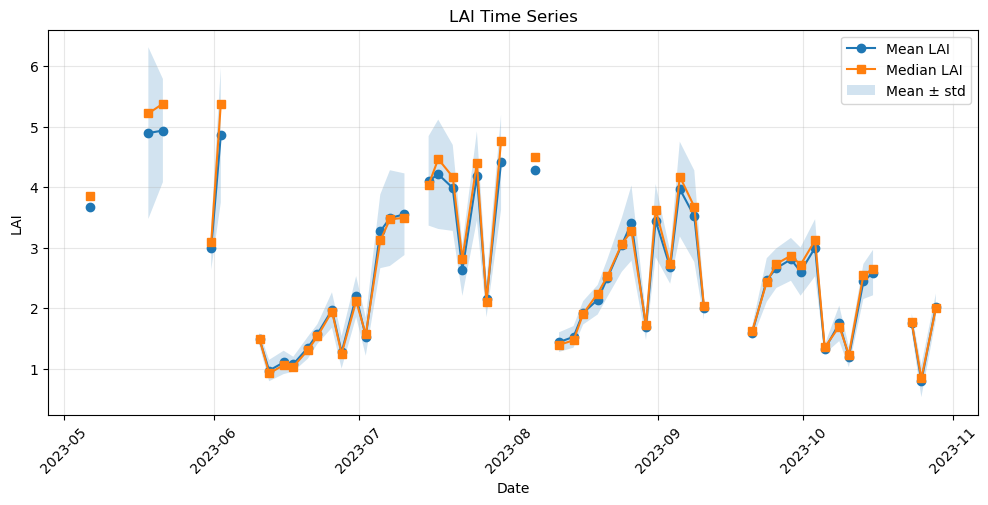

In [11]:
if lai_stats_df.empty:
    raise ValueError("No zonal statistics available to plot.")

plot_df = lai_stats_df.sort_values("time")
lower = plot_df["mean_lai"] - plot_df["std_lai"]
upper = plot_df["mean_lai"] + plot_df["std_lai"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["time"], plot_df["mean_lai"], marker="o", label="Mean LAI")
ax.plot(plot_df["time"], plot_df["median_lai"], marker="s", label="Median LAI")
ax.fill_between(plot_df["time"], lower, upper, alpha=0.2, label="Mean ± std")
ax.set_title("LAI Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("LAI")
ax.grid(True, alpha=0.3)
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.show()